<a href="https://colab.research.google.com/github/abrown12005/BME-4972_4973/blob/main/ImagesInMedicine/HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from scipy.stats import ttest_ind

RunningInCOLAB = 'google.colab' in str(get_ipython())
if RunningInCOLAB:
    # clone github repo with the data
    !git clone https://github.com/abrown12005/BME-4972_4973.git
    %cd BME-4972_4973/ImagesInMedicine

#Load and read the data
file_path = 'HW4.csv'
data = pd.read_csv(file_path,header=None)

healthy = data[0].to_numpy()
Schmooples = data[1].to_numpy()

Cloning into 'BME-4972_4973'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 57 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 271.52 KiB | 2.61 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine


P-Value:1.4108101454349842e-14
T-Statistic:-8.32


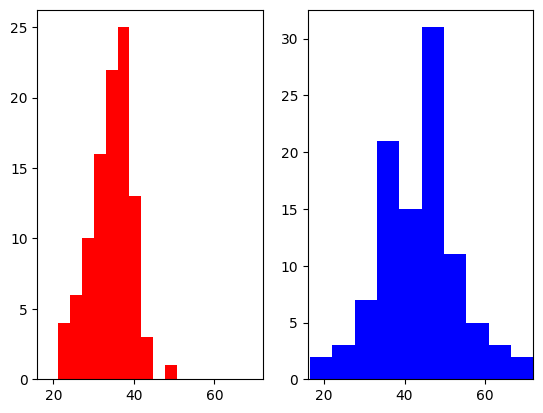

In [167]:
#Problem 1
#What is the probability that these two results came from the same dataset?
t_test = ttest_ind(healthy,Schmooples)

#Get the max and min to have the same x limits
x_max = np.maximum(np.max(healthy),np.max(Schmooples))
x_min = np.minimum(np.min(healthy),np.min(Schmooples))

fig, (ax1,ax2) = plt.subplots(1,2)
ax1.hist(healthy,color='r',bins=10)
ax1.set_xlim(int(x_min),int(x_max))

ax2.hist(Schmooples,color='b',bins=10)
ax2.set_xlim(int(x_min),int(x_max))

print(f'P-Value:{t_test.pvalue}')
print(f'T-Statistic:{t_test.statistic:.4}')

With a pvalue that low and a t-statistic that high(or very negative), it is very unlikely that these two sets of results emerged from the same dataset.

Text(0.5, 1.0, 'QQ Plot')

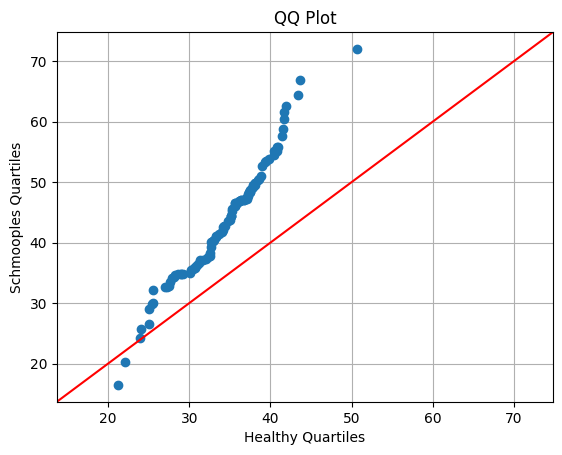

In [168]:
#Problem 2
#Create a QQ plot of this data
pp_x = sm.ProbPlot(healthy)
pp_y = sm.ProbPlot(Schmooples)
fig = sm.qqplot_2samples(pp_x, pp_y, line='45')
plt.grid('on')
plt.xlabel('Healthy Quartiles')
plt.ylabel('Schmooples Quartiles')
plt.title('QQ Plot')

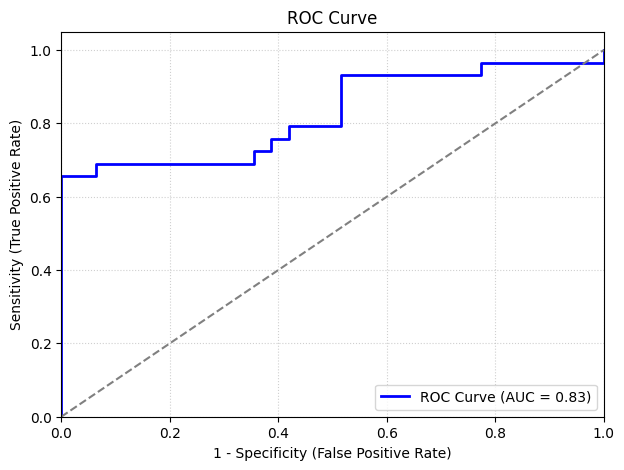

In [169]:
#Problem 3
#Make an ROC curve of this data
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix

# 1. Prepare the data for a binary classification task
# Combine the two distributions into a single feature array and reshape it to 2D
X_combined = np.concatenate((healthy, Schmooples)).reshape(-1, 1)

# Create corresponding binary labels: 0 for 'healthy' and 1 for 'Schmooples'
y_labels = np.concatenate((np.zeros(len(healthy)), np.ones(len(Schmooples))))

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_labels, test_size=0.3, random_state=42)

# 3. Train a classifier
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Get predicted probabilities for the positive class (class 1)
# predict_proba returns [prob_class_0, prob_class_1]
y_probs = model.predict_proba(X_test)[:, 1]

# 5. Calculate True Positive Rate (Sensitivity) and False Positive Rate (1 - Specificity)
# 'fpr' stands for False Positive Rate, 'tpr' stands for True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 6. Calculate Area Under the Curve (AUC)
auc_score = roc_auc_score(y_test, y_probs)

# 7. Plot the ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')

# Plot the baseline (random guessing)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Adjust layout to reflect Sensitivity and Specificity
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [170]:
#Problem 4
#Identify the best threshold at which healthy/schmooples cases are best separated
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
optimal_threshold = thresholds[best_idx]

print(f"J statistic: {optimal_threshold:.3f}")
print(f"TPR: {tpr[best_idx]:.2f}, FPR: {fpr[best_idx]:.2f}")

J statistic: 0.598
TPR: 0.66, FPR: 0.00


In [171]:
#Problem 5
#Make a confusion matrix for the data given your choice of threshold
y_probs_full = model.predict_proba(X_combined)[:, 1]

predicted_full = (y_probs_full >= optimal_threshold).astype(int)

#Make sure true positives are in the upper left side
cm = confusion_matrix(y_labels, predicted_full, labels=[1, 0])

#Label the matrix
print('          Positive    Negative')
print('Positive     {}         {}'.format(cm[0,0], cm[0,1]))
print('Negative     {}          {}'.format(cm[1,0], cm[1,1]))

          Positive    Negative
Positive     62         38
Negative     8          92


In [172]:
#Problem 6
#What is the sensitivity and specificity of the 'plook' index given your threshold?

Sn = cm[0,0] / (cm[0,0] + cm[0,1])
Sp = cm[1,1] / (cm[1,1] + cm[1,0])

print(f'Sensitivity:{Sn:.4f}\nSpecificity:{Sp:.4f}')

Sensitivity:0.6200
Specificity:0.9200


Problems 1, 2, 4, and 6 were created by hand. Problems 3 and 5 were helped with Colab Gemini.